In [72]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

In [73]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m'

def colored_text(color, txt):
    return color + str(txt) + RESET

In [74]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_caract = []

for year in years:
    df_caract_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"caract-{year}.csv"), encoding="utf-8", sep = ";")
    df_caract.append(df_caract_year)

df_caract = pandas.concat(df_caract)
df_caract.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,201900000001,30,11,2019,01:30,4,93,93053,1,1,1,2,AUTOROUTE A3,"48,8962100","2,4701200"
1,201900000002,30,11,2019,02:50,3,93,93066,1,1,1,6,AUTOROUTE A1,"48,9307000","2,3688000"
2,201900000003,28,11,2019,15:15,1,92,92036,1,1,1,4,AUTOROUTE A86,"48,9358718","2,3191744"
3,201900000004,30,11,2019,20:20,5,94,94069,1,1,1,4,A4,"48,8173295","2,4281502"
4,201900000005,30,11,2019,04:00,3,94,94028,1,1,1,2,A86 INT,"48,7763620","2,4332540"


In [75]:
# Drop ["adr","dep","com"] as we will work in our analysis with latitude and logitude 
# and they contain the location information already and decribed in a better way
df_caract.drop(columns=["adr","dep","com"],inplace=True)

In [76]:
df_caract.info()

<class 'pandas.DataFrame'>
Index: 327628 entries, 0 to 54401
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Num_Acc  327628 non-null  int64
 1   jour     327628 non-null  int64
 2   mois     327628 non-null  int64
 3   an       327628 non-null  int64
 4   hrmn     327628 non-null  str  
 5   lum      327628 non-null  int64
 6   agg      327628 non-null  int64
 7   int      327628 non-null  int64
 8   atm      327628 non-null  int64
 9   col      327628 non-null  int64
 10  lat      327628 non-null  str  
 11  long     327628 non-null  str  
dtypes: int64(9), str(3)
memory usage: 32.5 MB


In [77]:
# making sure the format is correct
df_caract["lat"] = pandas.to_numeric(
    df_caract["lat"].str.replace(",", "."),
    errors="coerce"
)

df_caract["long"] = pandas.to_numeric(
    df_caract["long"].str.replace(",", "."),
    errors="coerce"
)

In [78]:
df_caract["Num_Acc"].duplicated().sum()

np.int64(0)

In [79]:
# Checking missing values
df_caract = df_caract.replace(-1, pandas.NA)
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           9
agg           0
int          14
atm          26
col        1619
lat           0
long          1
dtype: int64

In [80]:
# next we are printing the features that have small number of missing values 
cat_small_na = df_caract.columns[(df_caract.isna().sum() < 5000) & (df_caract.isna().sum() > 0)]
print(cat_small_na)
# And we are going to impute these by the most frequent category
imputer = SimpleImputer(strategy="most_frequent")

df_caract[cat_small_na] = df_caract[cat_small_na].replace({pandas.NA: np.nan})
df_caract[cat_small_na] = imputer.fit_transform(df_caract[cat_small_na])
# checking that everything is good now
df_caract.isna().sum()

Index(['lum', 'int', 'atm', 'col', 'long'], dtype='str')


Num_Acc    0
jour       0
mois       0
an         0
hrmn       0
lum        0
agg        0
int        0
atm        0
col        0
lat        0
long       0
dtype: int64

In [81]:
# converting the columns to the correct type
column_names_to_int = ["jour", "mois", "lum", "agg", "int", "atm", "col"]

df_caract[column_names_to_int] = df_caract[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [82]:
# and just for latitude and longitude separately because these should be real numbers
df_caract[["lat", "long"]] = df_caract[["lat", "long"]].astype("float64")

In [83]:
# let's check the distribution
df_caract[["lat", "long"]].describe()

,lat,long
count,327628.000000,327628.000000
mean,44.343658,2.171736
std,12.244762,19.084446
min,-61.425660,-178.158090
25%,44.736676,1.283565
50%,47.825103,2.391478
75%,48.860313,4.795682
max,63.568066,174.023438


In [84]:
# in our analysis, we have decided to consider only accidents from metropolitan France, 
# but prior to delete other locations, let us check that their proportion in the dataset is not too big
# in this case approximatively 5.5 %, which is quite small, so we will delete these rows
invalid_lat = df_caract[
    (df_caract["lat"] < 41) | (df_caract["lat"] > 51) |
    (df_caract["long"] < -5) | (df_caract["long"] > 10)
]

print(f"Proportion of accidents outside metropolitan France: {len(invalid_lat) / len(df_caract) * 100:.3f} %")

Proportion of accidents outside metropolitan France: 5.523 %


In [85]:
# deleting accidents outside metropolitain area of France
df_caract = df_caract[
    (df_caract["lat"].between(41, 51)) &
    (df_caract["long"].between(-5, 10))
]

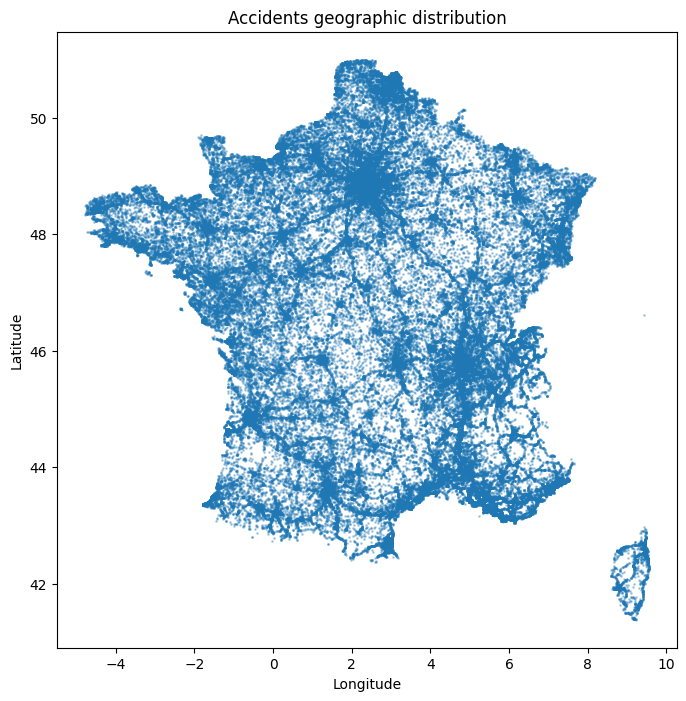

In [86]:
# let's plot the longitude and latitude
# we can see clearly French borders, so looks legitimate
plt.figure(figsize=(8, 8))
plt.scatter(df_caract["long"], df_caract["lat"], s=1, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accidents geographic distribution")
plt.show()

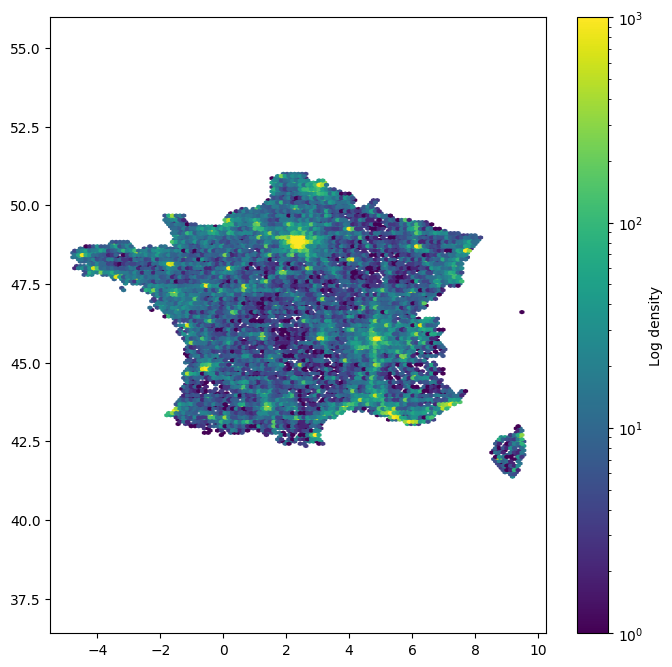

In [87]:
# to see more clearly let's also plot the denisty
# from this plot we can notice that a big proportion of accidents 
# happen in Ile de France and in other big cities of France, which also looks true
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract["long"],
    df_caract["lat"],
    gridsize=120,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=1000)
)

plt.colorbar(hb, label="Log density")
plt.axis("equal")
plt.show()

In [88]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("data_clean/df_usagers_clean.csv")

df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(df_caract, on='Num_Acc', how='left')

target = "grav_bin"

In [89]:
# checking how many rows have missing values after merging
# we can see that some accodents id were not present in the "usagers" table so we have to delete them from the "caract" table
df_caract_with_target.isna().sum()


Num_Acc         0
grav_bin        0
jour        42167
mois        42167
an          42167
hrmn        42167
lum         42167
agg         42167
int         42167
atm         42167
col         42167
lat         42167
long        42167
dtype: int64

In [90]:
# and removing these rows
df_caract_with_target.dropna()

,Num_Acc,grav_bin,jour,mois,an,hrmn,lum,agg,int,atm,col,lat,long
0,201900000001,0,30.0,11.0,2019.0,01:30,4.0,1.0,1.0,1.0,2.0,48.896210,2.470120
1,201900000001,0,30.0,11.0,2019.0,01:30,4.0,1.0,1.0,1.0,2.0,48.896210,2.470120
2,201900000001,0,30.0,11.0,2019.0,01:30,4.0,1.0,1.0,1.0,2.0,48.896210,2.470120
3,201900000002,0,30.0,11.0,2019.0,02:50,3.0,1.0,1.0,1.0,6.0,48.930700,2.368800
4,201900000003,0,28.0,11.0,2019.0,15:15,1.0,1.0,1.0,1.0,4.0,48.935872,2.319174
...,...,...,...,...,...,...,...,...,...,...,...,...,...
733054,202400054401,0,30.0,11.0,2024.0,15:40,1.0,2.0,1.0,1.0,3.0,48.832862,2.243940
733055,202400054401,0,30.0,11.0,2024.0,15:40,1.0,2.0,1.0,1.0,3.0,48.832862,2.243940
733056,202400054402,0,10.0,7.0,2024.0,08:30,1.0,2.0,1.0,1.0,4.0,48.783300,2.466600
733057,202400054402,0,10.0,7.0,2024.0,08:30,1.0,2.0,1.0,1.0,4.0,48.783300,2.466600


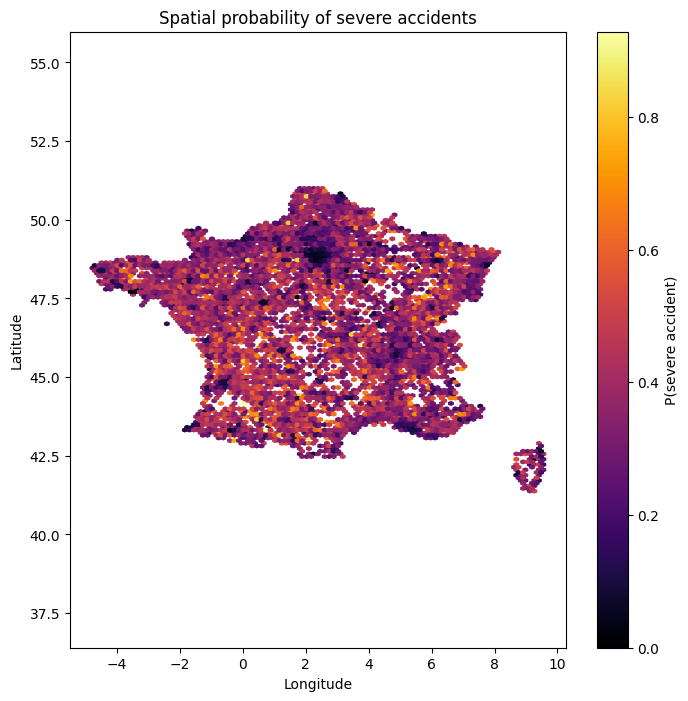

In [91]:
# Let's also plot the proportion of severe accidents by place
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract_with_target["long"],
    df_caract_with_target["lat"],
    C=df_caract_with_target["grav_bin"],
    reduce_C_function=np.mean, # probability of severe
    gridsize=100,
    cmap="inferno",
    mincnt=10 # ignore low-sample cells
)

plt.colorbar(hb, label="P(severe accident)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial probability of severe accidents")

plt.axis("equal")
plt.show()

In [92]:
# Next we pass to handling dates and time

# before checking the distribution we need to convert it to int
df_caract["hrmn_num"] = df_caract["hrmn"].str.replace(":", "", regex=False).astype(int)

# first let's look at the distribution of month, day and time
df_caract[['mois', 'jour', 'hrmn_num']].describe()
# we can see that the values of month, day and hour:minutes is in correct intervals, respectively: 1 to 12, 1 to 31 
# and 0 (for 00:00) to 2359 (for 23:59)

,mois,jour,hrmn_num
count,309533.000000,309533.000000,309533.000000
mean,6.709769,15.632488,1374.590832
std,3.357667,8.731284,550.828135
min,1.000000,1.000000,0.000000
25%,4.000000,8.000000,950.000000
50%,7.000000,16.000000,1450.000000
75%,10.000000,23.000000,1810.000000
max,12.000000,31.000000,2359.000000


In [93]:
# next we will design some new features that will capture more the moment of accidents
df_caract["date"] = pandas.to_datetime(
    dict(year=df_caract["an"],
    month=df_caract["mois"],
    day=df_caract["jour"]),
    errors="coerce"
)

df_caract["day_of_year"] = df_caract["date"].dt.dayofyear
df_caract["weekday"] = df_caract["date"].dt.weekday
df_caract["month"] = df_caract["date"].dt.month
df_caract["year"] = df_caract["date"].dt.year

In [94]:
# first let's define the day of the year with cos and sin 
# to better measure the distance between 2 days in the interval from 1 to 365
df_caract["day_sin"] = np.sin(2 * np.pi * df_caract["day_of_year"] / 365)
df_caract["day_cos"] = np.cos(2 * np.pi * df_caract["day_of_year"] / 365)

# similar with month (in the interval from 1 to 12)
df_caract["month_sin"] = np.sin(2 * np.pi * df_caract["month"] / 12)
df_caract["month_cos"] = np.cos(2 * np.pi * df_caract["month"] / 12)

# similar with weekday (in the interval from 1 to 7)
df_caract["weekday_sin"] = np.sin(2 * np.pi * df_caract["weekday"] / 7)
df_caract["weekday_cos"] = np.cos(2 * np.pi * df_caract["weekday"] / 7)

# and similar with hour (in the interval from 1 to 24), but here we first need to convert it to the right format
df_caract["hrmn"] = df_caract["hrmn"].astype(str).str.strip()
df_caract["hour"] = df_caract["hrmn"].str[:2].astype(int)

df_caract["hour_sin"] = np.sin(2 * np.pi * df_caract["hour"] / 24)
df_caract["hour_cos"] = np.cos(2 * np.pi * df_caract["hour"] / 24)

In [95]:
# we also create a new feature to see whether it is a weekend or not
df_caract["is_weekend"] = df_caract["weekday"].isin([5, 6]).astype(int)

In [96]:
# now we can drop all the columns that we are not going to use, as we have created better ones
df_caract.drop(columns=["date", "day_of_year", "weekday", "hour", "month", "year", "hrmn", "hrmn_num", "an", "jour", "mois"], inplace=True)

In [97]:
# defining our sets of features depending on their type
categorical_features = ['lum', 'agg', 'int', 'atm', 'col']
binary_features = ["is_weekend"]     
numerical_features = ['lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos']

features = categorical_features + binary_features + numerical_features

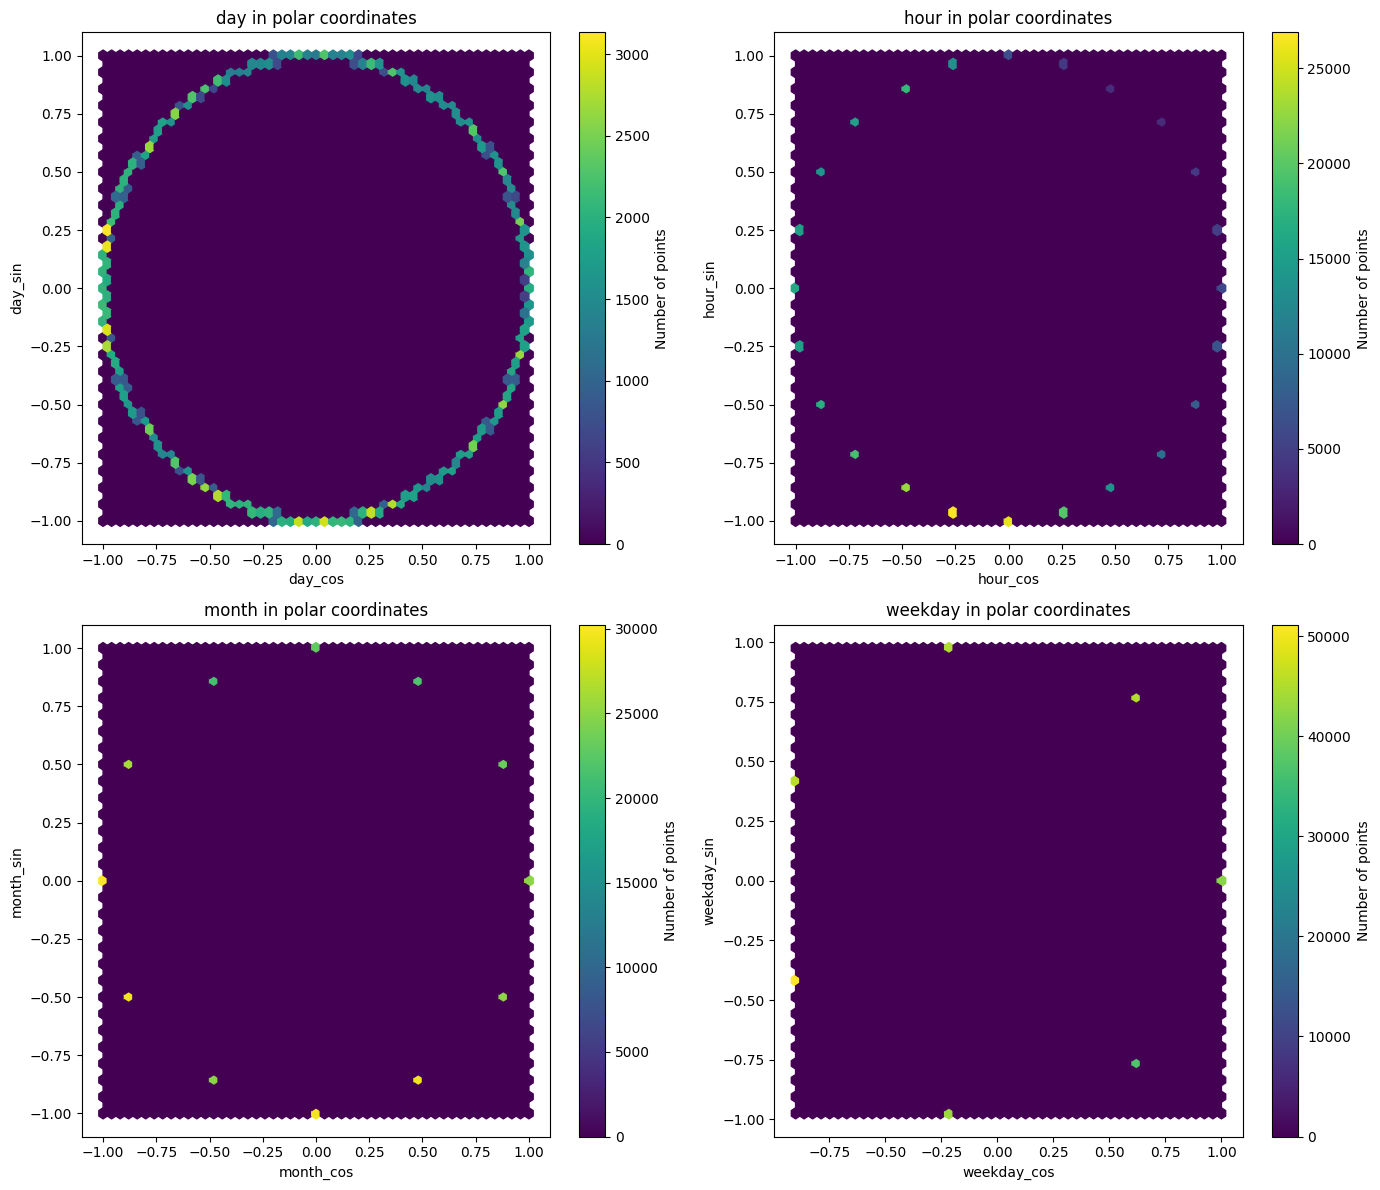

In [98]:
# let's plot the distribution of accidents in temporal space
pairs = [('day_cos', 'day_sin'), ('hour_cos', 'hour_sin'), ('month_cos', 'month_sin'), ('weekday_cos', 'weekday_sin')]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    hb = ax.hexbin(df_caract[x], df_caract[y], gridsize=50, cmap='viridis')
    fig.colorbar(hb, ax=ax, label='Number of points')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x.split('_')[0]} in polar coordinates")

plt.tight_layout()
plt.show()

In [99]:
# next, let's continue our analysis with target label, we are combining the second time because we have modified the "caract" table
df_usagers = pandas.read_csv("data_clean/df_usagers_clean.csv")
df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(df_caract, on='Num_Acc', how='left')

In [100]:
# checking how many rows have missing values after merging and deleting as previsouly
df_caract_with_target.isna().sum()
df_caract_with_target = df_caract_with_target.dropna()

In [101]:
# and then creating our analysis matrix, where we are going to replace numeric categories by their text description
df_caract_analyse = df_caract_with_target.copy()

In [102]:
# translating the spatial fetaures into more visual form with arctan2
df_caract_analyse['day_of_year'] = np.arctan2(df_caract_analyse['day_sin'], df_caract_analyse['day_cos'])
df_caract_analyse['day_of_year'] = (df_caract_analyse['day_of_year'] % (2*np.pi)) * 365 / (2*np.pi)

df_caract_analyse['hour'] = np.arctan2(df_caract_analyse['hour_sin'], df_caract_analyse['hour_cos'])
df_caract_analyse['hour'] = (df_caract_analyse['hour'] % (2*np.pi)) * 24 / (2*np.pi)

df_caract_analyse['month'] = np.arctan2(df_caract_analyse['month_sin'], df_caract_analyse['month_cos'])
df_caract_analyse['month'] = (df_caract_analyse['month'] % (2*np.pi)) * 12 / (2*np.pi)

df_caract_analyse['weekday'] = np.arctan2(df_caract_analyse['weekday_sin'], df_caract_analyse['weekday_cos'])
df_caract_analyse['weekday'] = (df_caract_analyse['weekday'] % (2*np.pi)) * 7 / (2*np.pi)     


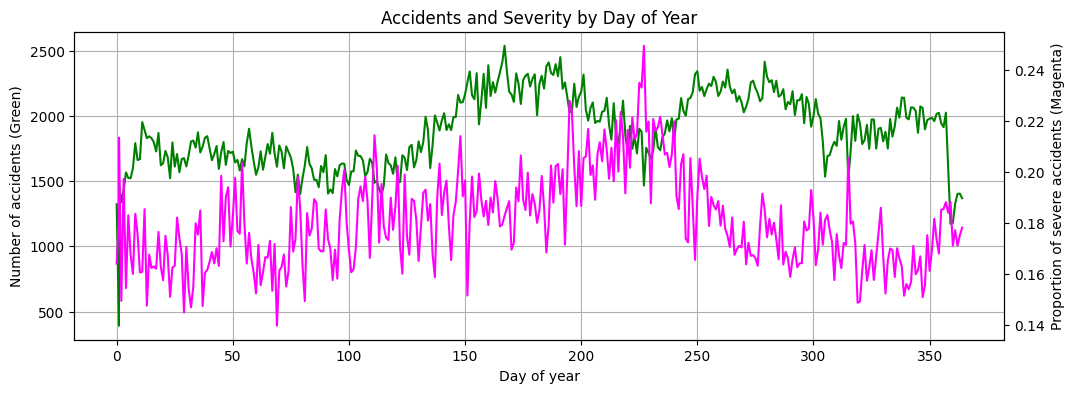

In [103]:
# next we are going to plot the day of the year by the number of accidents and precentage of the severity among them
daily_counts = df_caract_analyse.groupby('day_of_year')['grav_bin'].count()
daily_severe = df_caract_analyse.groupby('day_of_year')['grav_bin'].mean()

fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(daily_counts.index, daily_counts.values, color = "GREEN")
ax1.set_xlabel("Day of year")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(daily_severe.index, daily_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by Day of Year")
plt.show()

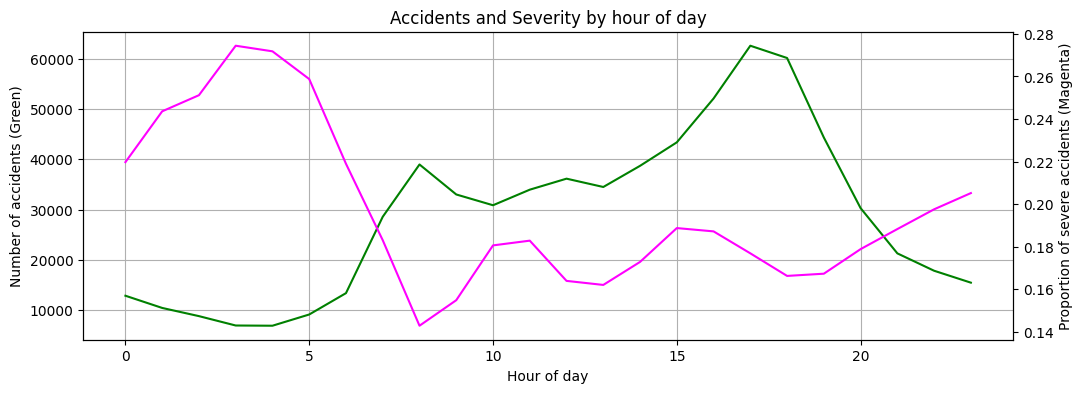

In [104]:
# same with the hour of the day
hourly_counts = df_caract_analyse.groupby('hour')['grav_bin'].count()
hourly_severe = df_caract_analyse.groupby('hour')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(hourly_counts.index, hourly_counts.values, color = "GREEN")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(hourly_severe.index, hourly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by hour of day")
plt.show()

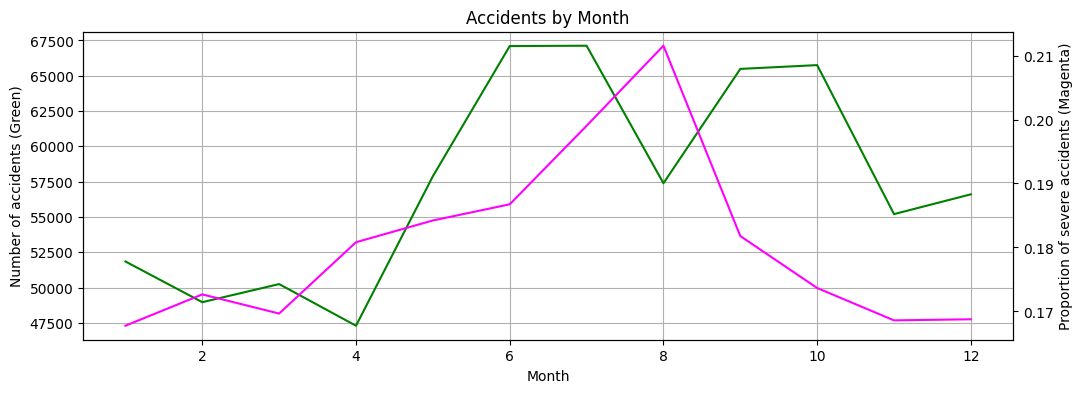

In [105]:
# same with the month of the year
monthly_counts = df_caract_analyse.groupby('month')['grav_bin'].count()
monthly_severe = df_caract_analyse.groupby('month')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(monthly_counts.index, monthly_counts.values, color = "GREEN")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(monthly_severe.index, monthly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents by Month")
plt.show()

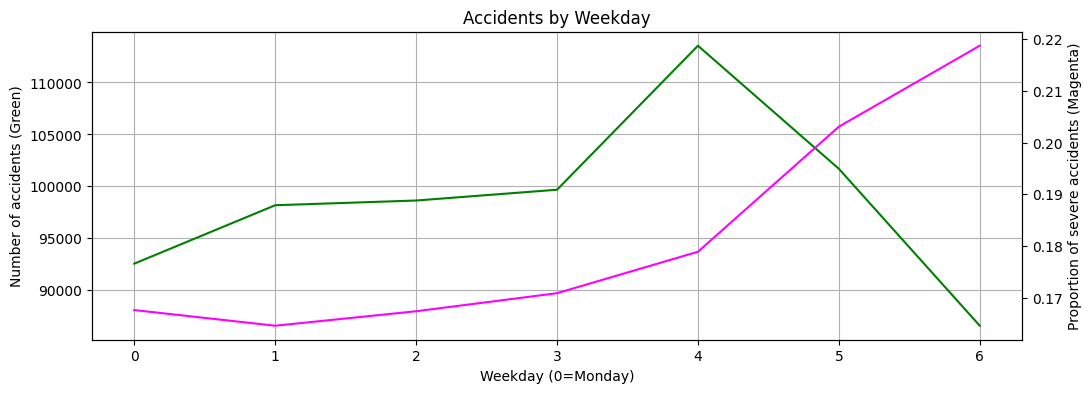

In [106]:
# same with the day of the week
weekly_counts = df_caract_analyse.groupby('weekday')['grav_bin'].count()
weekly_severe = df_caract_analyse.groupby('weekday')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(weekly_counts.index, weekly_counts.values, color = "GREEN")
ax1.set_xlabel("Weekday (0=Monday)")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(weekly_severe.index, weekly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents by Weekday")
plt.show()

In [107]:
mapping = {
    1: "Daylight",
    2: "Twilight or dawn",
    3: "Night without public lighting",
    4: "Night with public lighting not lit",
    5: "Night with public lighting lit"
}
df_caract_analyse["lum"] = df_caract_analyse["lum"].replace(mapping)

mapping = {
    1: "Outside built-up area",
    2: "Inside built-up area"
}
df_caract_analyse["agg"] = df_caract_analyse["agg"].replace(mapping)

mapping = {
    1: "No intersection",
    2: "X intersection",
    3: "T intersection",
    4: "Y intersection",
    5: "Intersection with more than 4 branches",
    6: "Roundabout",
    7: "Square",
    8: "Level crossing",
    9: "Other intersection"
}
df_caract_analyse["int"] = df_caract_analyse["int"].replace(mapping)

mapping = {
    1: "Normal",
    2: "Light rain",
    3: "Heavy rain",
    4: "Snow / hail",
    5: "Fog / smoke",
    6: "Strong wind / storm",
    7: "Dazzling weather (glare)",
    8: "Overcast",
    9: "Other"
}
df_caract_analyse["atm"] = df_caract_analyse["atm"].replace(mapping)

mapping = {
    1: "Two vehicles – head-on",
    2: "Two vehicles – rear-end",
    3: "Two vehicles – side collision",
    4: "Three or more vehicles – chain collision",
    5: "Three or more vehicles – multiple collisions",
    6: "Other collision",
    7: "No collision"
}
df_caract_analyse["col"] = df_caract_analyse["col"].replace(mapping)

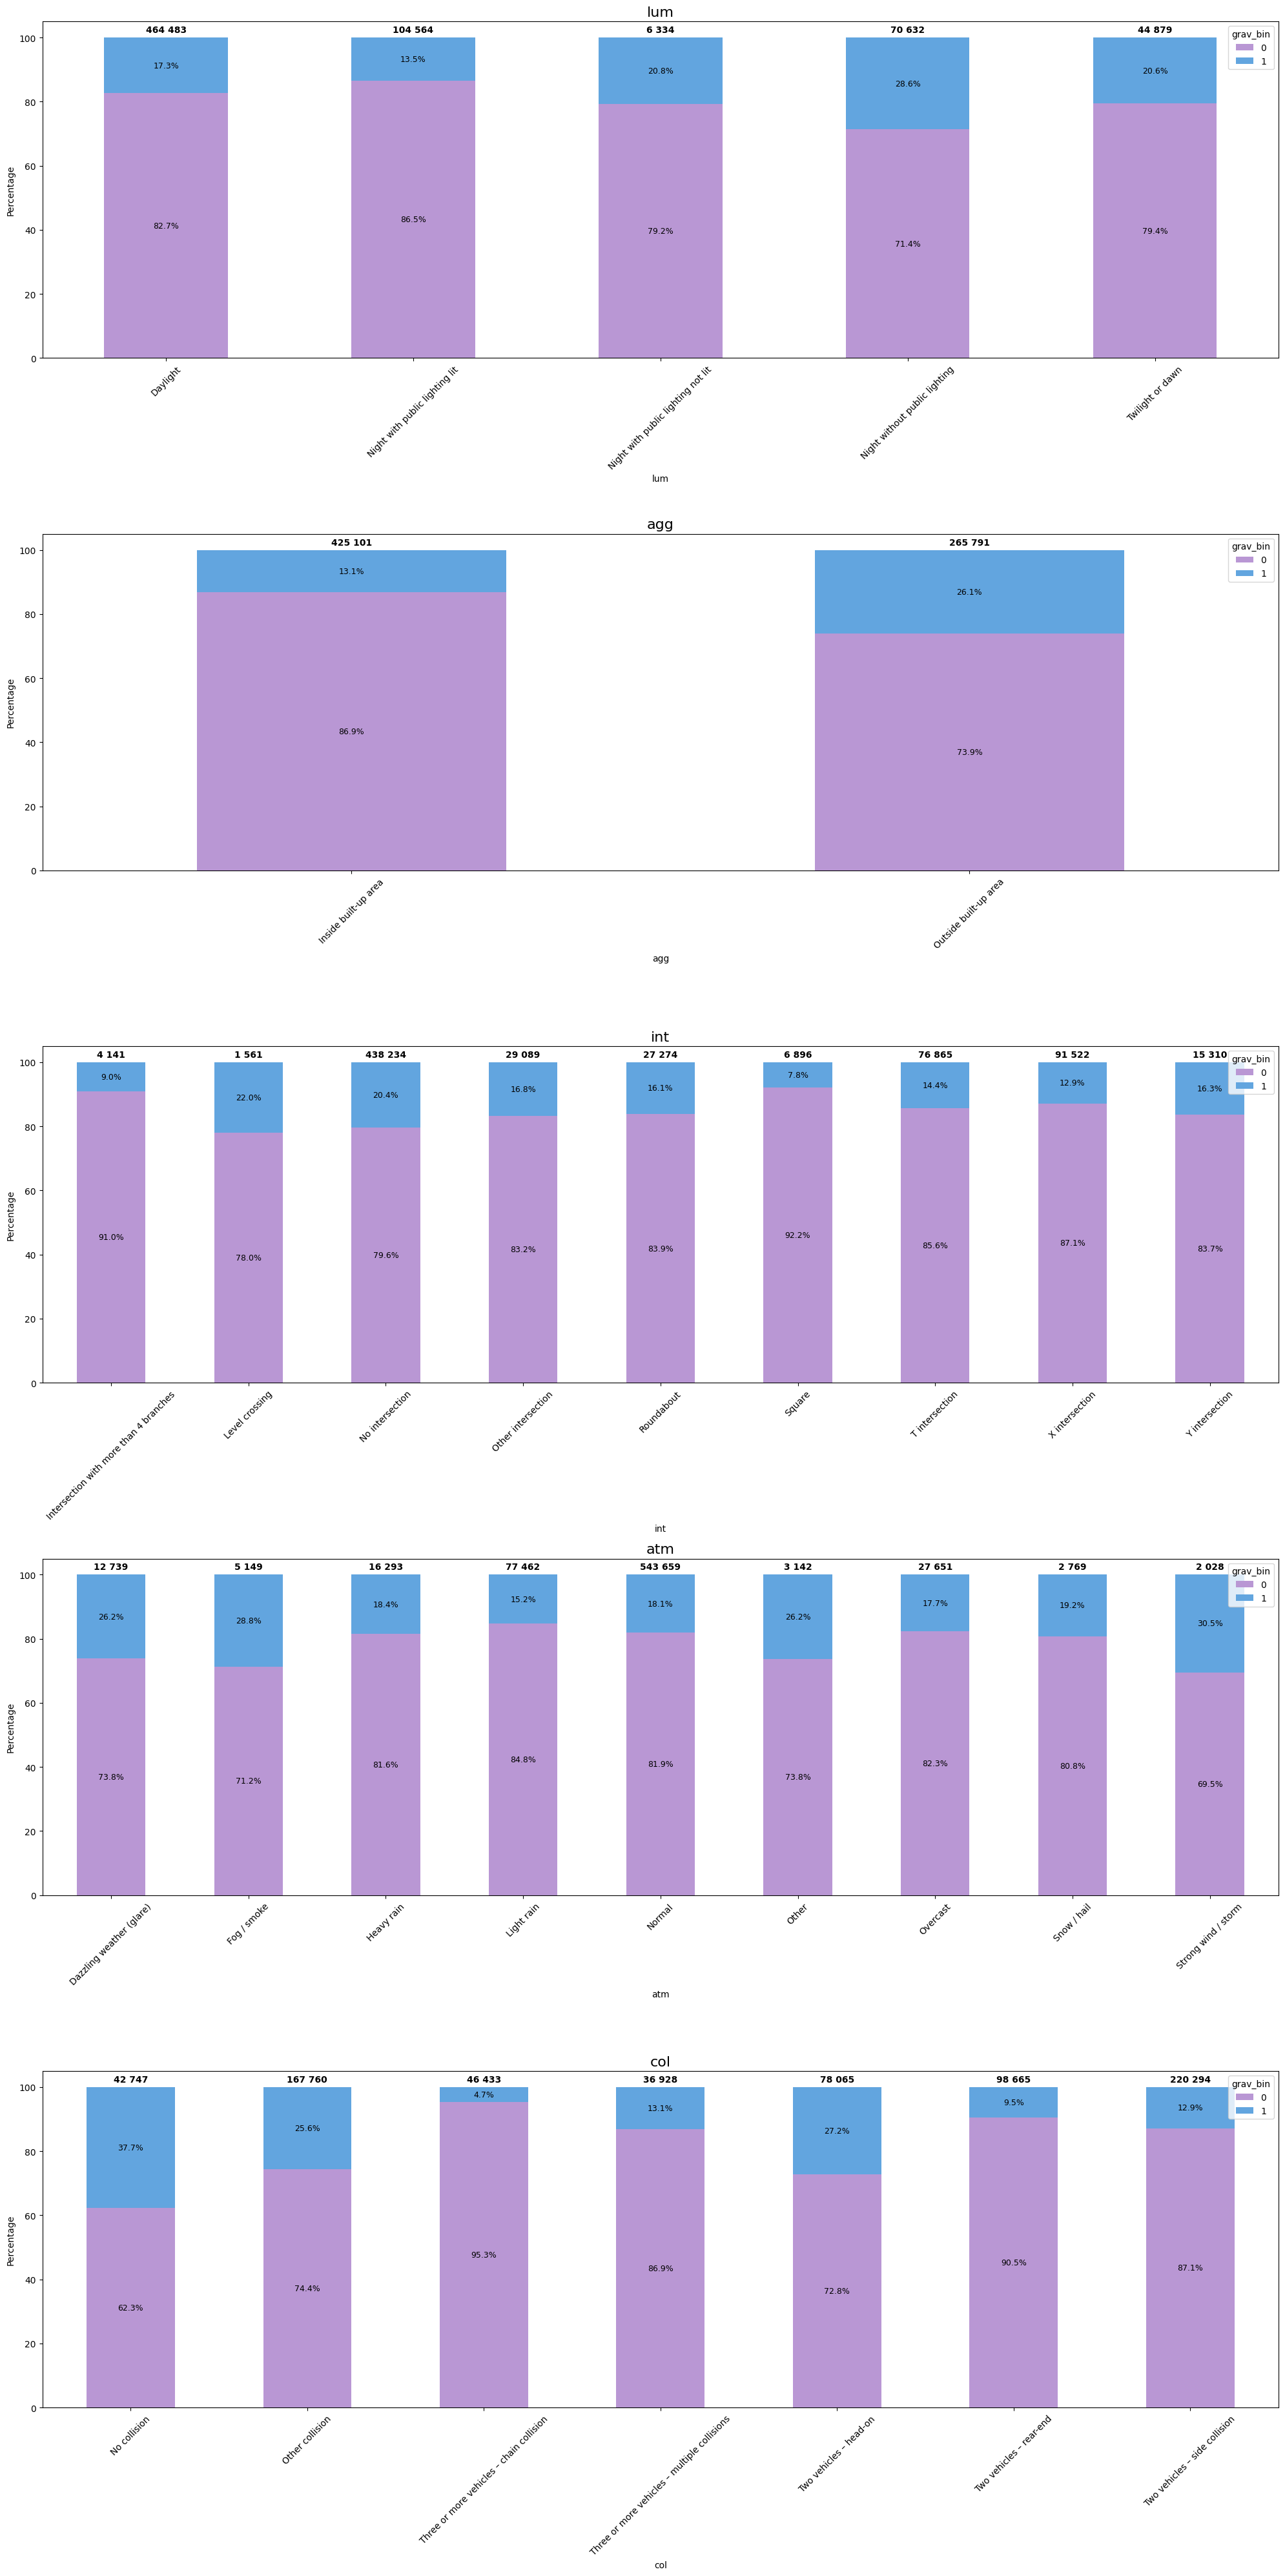

In [108]:
# Finally let's see the counts and proportions by class of categorical features

fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_caract_analyse = df_caract_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_caract_analyse[feature],
        df_caract_analyse[target],
        normalize="index"
    ) * 100

    counts = df_caract_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [109]:
def latex_escape_category(x):
    x = str(x)
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

all_features_to_analyse = categorical_features + binary_features
for feature in all_features_to_analyse:
    counts = df_caract_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

print("\n".join(output_lines))

\texttt{lum} & Daylight & 464 483 & 82.7 & 17.3 \\
 & Night with public lighting lit & 104 564 & 86.5 & 13.5 \\
 & Night with public lighting not lit & 6 334 & 79.2 & 20.8 \\
 & Night without public lighting & 70 632 & 71.4 & 28.6 \\
 & Twilight or dawn & 44 879 & 79.4 & 20.6 \\
\hline
\texttt{agg} & Inside built-up area & 425 101 & 86.9 & 13.1 \\
 & Outside built-up area & 265 791 & 73.9 & 26.1 \\
\hline
\texttt{int} & Intersection with more than 4 branches & 4 141 & 91.0 & 9.0 \\
 & Level crossing & 1 561 & 78.0 & 22.0 \\
 & No intersection & 438 234 & 79.6 & 20.4 \\
 & Other intersection & 29 089 & 83.2 & 16.8 \\
 & Roundabout & 27 274 & 83.9 & 16.1 \\
 & Square & 6 896 & 92.2 & 7.8 \\
 & T intersection & 76 865 & 85.6 & 14.4 \\
 & X intersection & 91 522 & 87.1 & 12.9 \\
 & Y intersection & 15 310 & 83.7 & 16.3 \\
\hline
\texttt{atm} & Dazzling weather (glare) & 12 739 & 73.8 & 26.2 \\
 & Fog / smoke & 5 149 & 71.2 & 28.8 \\
 & Heavy rain & 16 293 & 81.6 & 18.4 \\
 & Light rain & 7

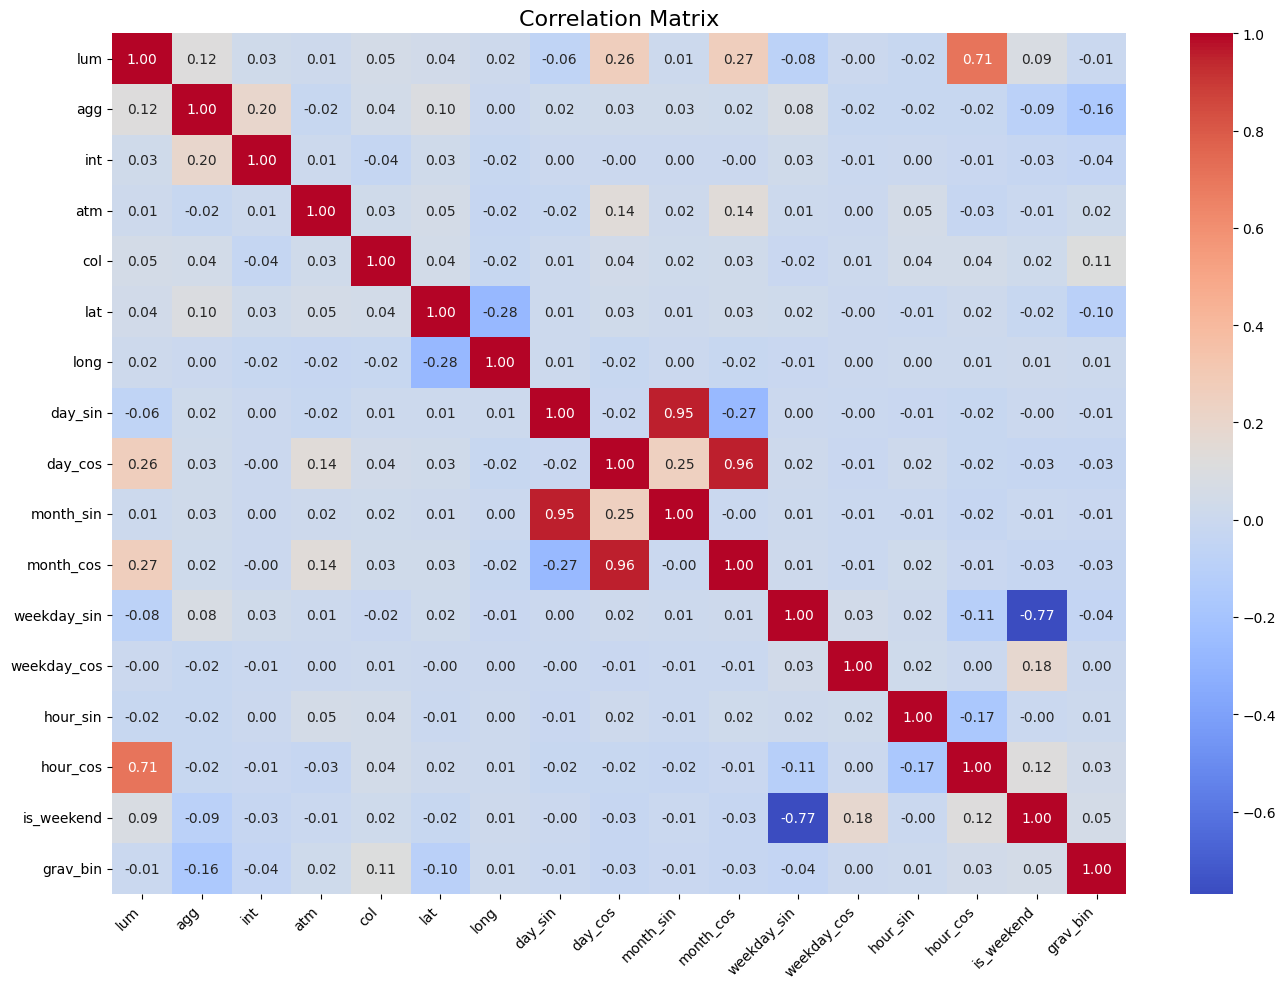

In [110]:
# plotting the correlation matrix
plt.figure(figsize=(14, 10))

sns.heatmap(df_caract_with_target[['lum', 'agg', 'int', 'atm', 'col', 'lat', 'long',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin',
       'weekday_cos', 'hour_sin', 'hour_cos', 'is_weekend', 'grav_bin']].corr(), cmap="coolwarm", annot=True, fmt=".2f", annot_kws={"size": 10})

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [111]:
# next let's see how well can we predict our target labels with these new features 
# first we are splitting our dataset
X = df_caract_with_target[categorical_features + numerical_features + binary_features]
y = df_caract_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [112]:
# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin_cat", "passthrough", binary_features)
    ]
)

# models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

# our pipelines depending on the method of sampling
pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under", RandomUnderSampler(random_state=20)),
        ("model", model)    
    ])

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (oversampling)"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (undersampling)"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

Model selection with cross-validation (oversampling)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    452630
           1       0.31      0.66      0.42    100083

    accuracy                           0.67    552713
   macro avg       0.60      0.66      0.59    552713
weighted avg       0.79      0.67      0.70    552713


 Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.81      0.83    452630
           1       0.29      0.35      0.32    100083

    accuracy                           0.73    552713
   macro avg       0.57      0.58      0.57    552713
weighted avg       0.75      0.73      0.74    552713


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.91      0.67      0.77    452630
           1       0.32      0.72      0.45    100083

    accuracy                           0.68    552713
   macro avg     

              precision    recall  f1-score   support

           0       0.92      0.67      0.77    113158
           1       0.32      0.72      0.45     25021

    accuracy                           0.68    138179
   macro avg       0.62      0.69      0.61    138179
weighted avg       0.81      0.68      0.71    138179



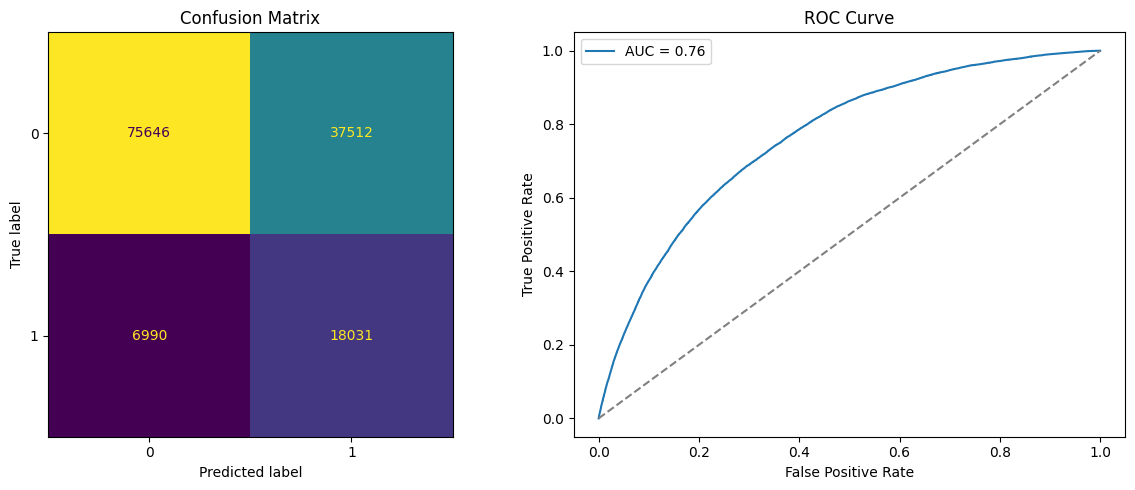

In [113]:
# similarly to "usagers" set of features, we can select the best model accroding to f1 score 
# (which in this case is also Gradient Boosting and we can take undersampling as it gives the same result as with oversampling)
# and then train on the entire train set et test on test set

# Train and predict
model = pipelines_under["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [114]:
# Finally we are going to save the dataset cleaned
df_caract.to_csv("data_clean/df_caract_clean.csv", index=False)